## Q2. Symmetric proposal distributions

In [1]:
import random
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from scipy.integrate import quad

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11

UNIFORM_COLOR = "#1f77b4"
RANDOM_WALK_COLOR = "#d160f1"
NORMAL_COLOR = "#2ca02c"
TRUE_DENSITY_COLOR = "#ff7f0e"

## Defined functions

In [2]:
# Fixed random generator
np.random.seed(0)
rng_proposal = np.random.default_rng(26)
rng_metropolis = np.random.default_rng(9)

# Target function
def target_fn(x, z):
    return np.exp(-x**4)/z

# Symmetric Proposal Functions
def uniform_proposal(x, step_size=0.01, rng=rng_proposal):
    """Uniform distribution to generate new step size
    Params:
        x (float): current position of x
        step_size (float): bounds of uniform func

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + rng.uniform(-step_size, step_size)
    return updated_x

def rw_proposal(x, step_size=0.01, rng=rng_proposal):
    """Uniform distribution to choose left and right direction and take the predefined step
    Params:
        x (float): current position of x
        step_size (float): size of each step

    Returns:
        updated_x (float): next position of x
    """
    decider = rng.uniform(0, 1)
    if decider > 0.5:
        updated_x = x + step_size
    else:
        updated_x = x - step_size
    return updated_x

def normal_proposal(x, sigma=1, rng=rng_proposal):
    """
    N(x, sigma^2) distribution to generate new step size
    Params:
        x (float): current position of x
        sigma (float): standard deviation

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + rng.normal(0, sigma)
    return updated_x

In [3]:
# Metropolis sampler with symmetric proposal function
def universal_metropolis_sampler(dist, num_samples, initial_x, z,
                                 step_size=None, sigma=None, df=None):
    """Metropolis sampler for all symmetric proposal functions
    Params:
        dist: symmetric proposal distributions (uniform, rw, normal, student)
        num_samples (int): number of samples for simulation
        initial_x (float): initial position of x

    Returns:
        samples (np.array): arrays of generated samples
    """
    lst = {"uniform": uniform_proposal,
           "rw": rw_proposal,
           "normal": normal_proposal,
           }

    samples = [initial_x]
    x = initial_x
    accepted = 0 # counter for accepted proposals

    for _ in range(num_samples - 1):
        sampler = lst[dist]
        # Call the function with parameter
        if dist in ["uniform", "rw"]:
            x_proposal = sampler(x, step_size)
        elif dist == "normal":
            x_proposal = sampler(x, sigma)
        elif dist == "student":
            x_proposal = sampler(x, df)
        else:
            raise ValueError(f"{dist} distribution is unavailable.")

        # Metropolis acceptance step
        acceptance_ratio = target_fn(x_proposal, z) / target_fn(x, z)
        if np.random.rand() < min(1, acceptance_ratio):
            x = x_proposal
            accepted += 1

        samples.append(x)

    acceptance_rate = accepted / (num_samples - 1)
    # Message
    print(f"Acceptance rate: {acceptance_rate:.4f}")

    return np.array(samples), acceptance_rate

## 2a. Estimate the normalization factor Z

In [4]:
Z = quad(lambda x: np.exp(-x**4), -np.inf, np.inf)[0]
print("Estimated normalization factor Z =", Z)

Estimated normalization factor Z = 1.8128049541109543


In [5]:
# Generate samples and number of bins
N1, N2, N3 = 50, 500, 5000
B1, B2, B3 = 30, 30, 30
INITIAL_X = 0.0
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

## 2b

In [6]:
# Generate samples and number of bins
N = 1000
B1, B2, B3 = 30, 30, 30
UNIFORM_STEP = 1
RW_STEP = 1
SIGMA = 1
INITIAL_X = 0.0
metropolis_results = {}
# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=UNIFORM_STEP)
samples_rw, acc_rw = universal_metropolis_sampler(dist="rw", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=RW_STEP)
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=SIGMA)

# Save results
metropolis_results["Uniform"] = {"samples": samples_uniform, "acceptance_rate": acc_uniform}
metropolis_results["Random Walk"] = {"samples": samples_rw, "acceptance_rate": acc_rw}
metropolis_results["Normal"] = {"samples": samples_normal, "acceptance_rate": acc_normal}

Acceptance rate: 0.7197
Acceptance rate: 0.4224
Acceptance rate: 0.5936


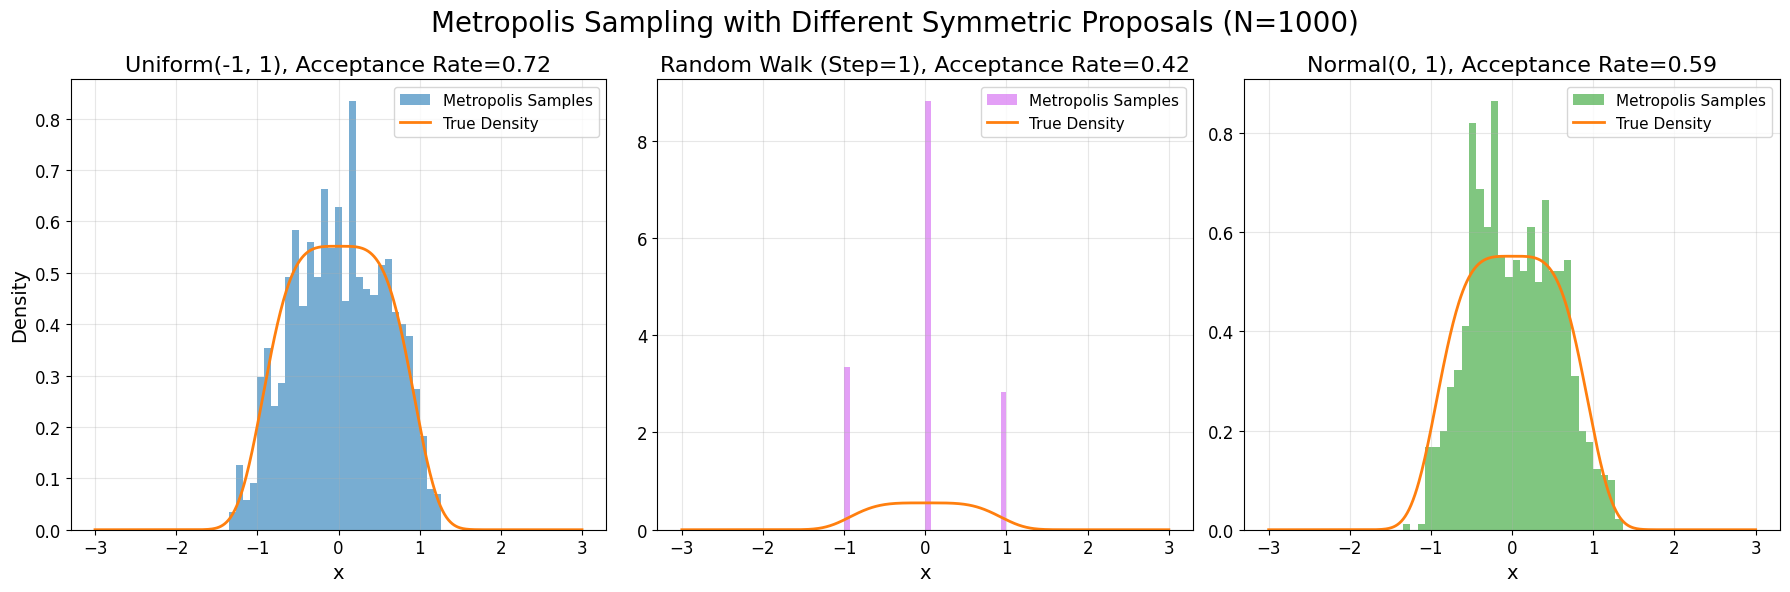

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# ---------- First plot ----------
ax[0].hist(samples_uniform,
           bins=B1,
           density=True,
           alpha=0.6,
           color=UNIFORM_COLOR,
           label="Metropolis Samples")

ax[0].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[0].set_title(
    f"Uniform(-{UNIFORM_STEP}, {UNIFORM_STEP}), Acceptance Rate={acc_uniform:.2f}",
    fontsize=TITLE_SIZE
)

ax[0].set_xlabel("x", fontsize=LABEL_SIZE)
ax[0].set_ylabel("Density", fontsize=LABEL_SIZE)

ax[0].tick_params(axis='both', labelsize=TICK_SIZE)

ax[0].grid(True, alpha=0.3)

ax[0].legend(fontsize=LEGEND_SIZE)

# ---------- Second plot ----------
ax[1].hist(samples_rw,
           bins=B2,
           density=True,
           alpha=0.6,
           color=RANDOM_WALK_COLOR,
           label="Metropolis Samples")

ax[1].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[1].set_title(
    f"Random Walk (Step={RW_STEP}), Acceptance Rate={acc_rw:.2f}",
    fontsize=TITLE_SIZE
)

ax[1].set_xlabel("x", fontsize=LABEL_SIZE)

ax[1].tick_params(axis='both', labelsize=TICK_SIZE)

ax[1].grid(True, alpha=0.3)

ax[1].legend(fontsize=LEGEND_SIZE)

# ---------- Third plot ----------
ax[2].hist(samples_normal,
           bins=B3,
           density=True,
           alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

ax[2].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[2].set_title(
    f"Normal(0, {SIGMA}), Acceptance Rate={acc_normal:.2f}",
    fontsize=TITLE_SIZE
)

ax[2].set_xlabel("x", fontsize=LABEL_SIZE)

ax[2].tick_params(axis='both', labelsize=TICK_SIZE)

ax[2].grid(True, alpha=0.3)

ax[2].legend(fontsize=LEGEND_SIZE)

# Global title
plt.suptitle(
    f"Metropolis Sampling with Different Symmetric Proposals (N={N})",
    fontsize=20,
)

# Better spacing
plt.tight_layout()

# High quality export
plt.savefig(
    "figures\\q2_compare_proposals.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Trace plots

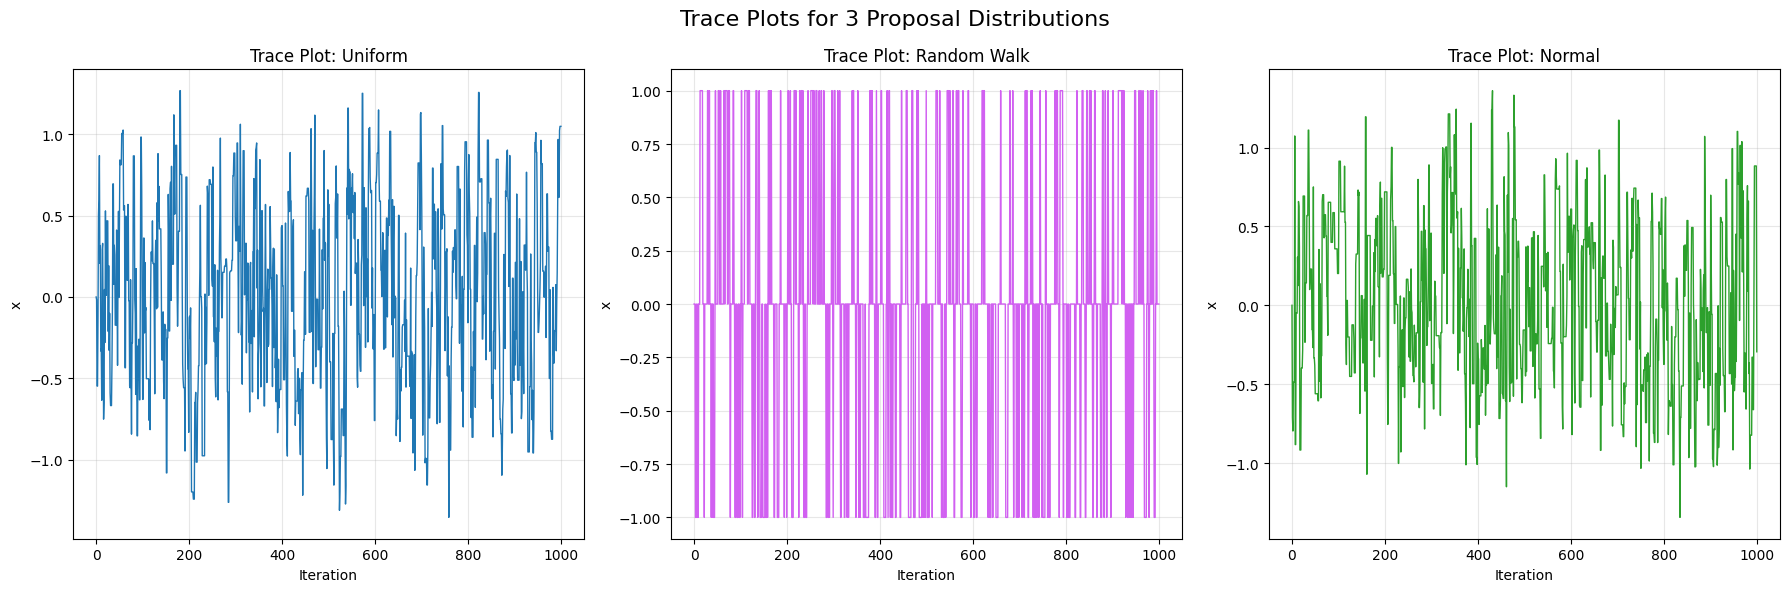

In [8]:
PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Random Walk": RANDOM_WALK_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]

    ax.plot(samples, linewidth=1, color=PROPOSAL_COLORS[proposal_name])

    ax.set_title(f"Trace Plot: {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("x")
    ax.grid(True, alpha=0.3)

plt.suptitle("Trace Plots for 3 Proposal Distributions", fontsize=16)
plt.tight_layout()
plt.savefig(
    "figures\\q2_trace_plots.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Running mean convergence
Since f(x) is symmetric around 0, the true mean is 0. The running mean should move toward 0 if sampling works well.

Uniform sample mean: 0.0190
Random Walk sample mean: -0.0340
Normal sample mean: 0.0265


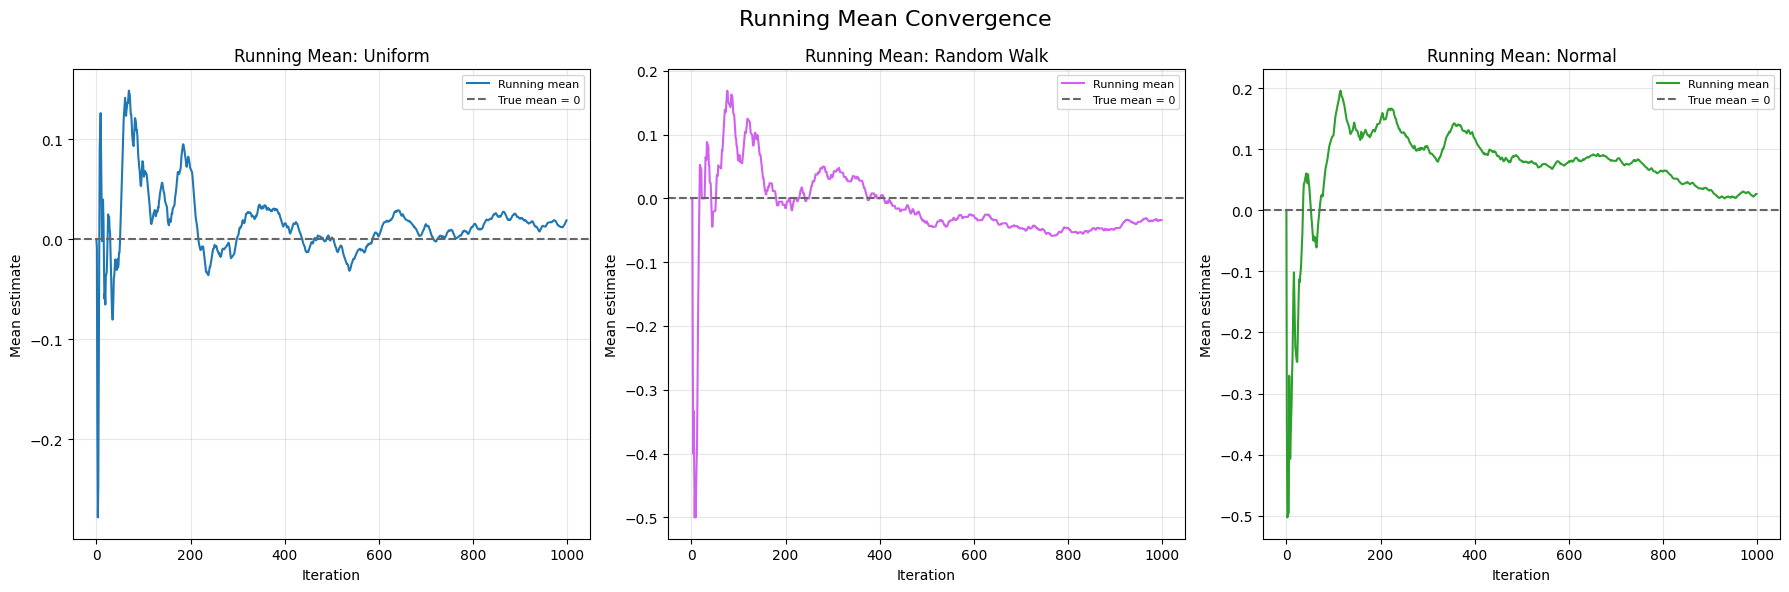

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    running_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)

    ax.plot(running_mean, linewidth=1.5, color=PROPOSAL_COLORS[proposal_name], label="Running mean")
    ax.axhline(0, linestyle="--", linewidth=1.5, color="#666666", label="True mean = 0")

    ax.set_title(f"Running Mean: {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean estimate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    sample_mean = np.mean(samples)
    print(f"{proposal_name} sample mean: {sample_mean:.4f}")
    
plt.suptitle("Running Mean Convergence", fontsize=16)
plt.tight_layout()
plt.savefig(
    "figures\\q2_running_mean_convergence.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Step 11: Autocorrelation function
Lower autocorrelation usually means better mixing. If autocorrelation stays high, samples are strongly dependent.

In [10]:
def autocorrelation(samples, max_lag=50):
    """
    Compute autocorrelation values up to max_lag.
    """

    samples = np.asarray(samples)
    samples_centered = samples - np.mean(samples)

    acf_values = []

    for lag in range(max_lag + 1):

        if lag == 0:
            acf_values.append(1.0)
        else:
            corr = np.corrcoef(
                samples_centered[:-lag],
                samples_centered[lag:]
            )[0, 1]
            acf_values.append(corr)

    return np.array(acf_values)

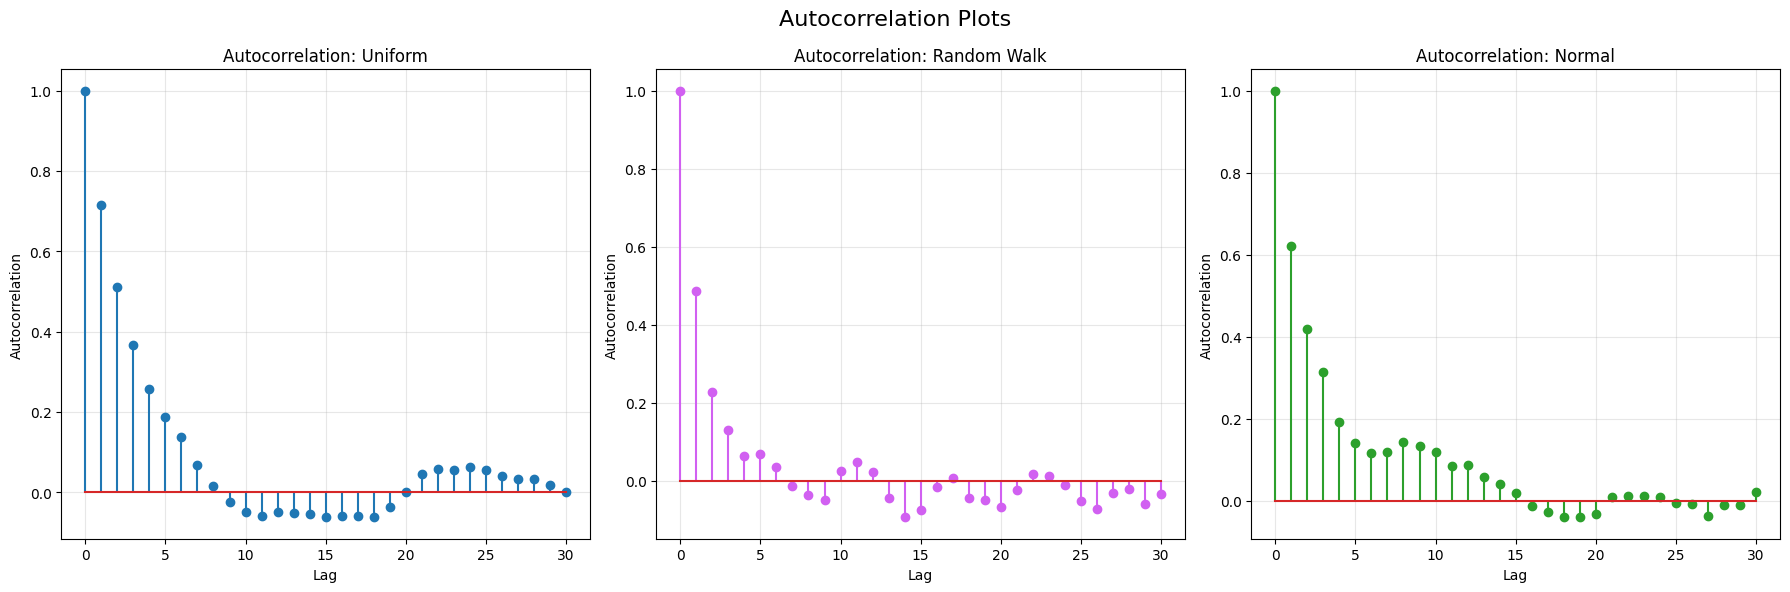

In [11]:
max_lag = 30


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    acf_values = autocorrelation(samples, max_lag=max_lag)

    markerline, stemlines, baseline = ax.stem(
        range(max_lag + 1),
        acf_values
    )
    plt.setp(markerline, color=PROPOSAL_COLORS[proposal_name])
    plt.setp(stemlines, color=PROPOSAL_COLORS[proposal_name])

    ax.set_title(f"Autocorrelation: {proposal_name}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.grid(True, alpha=0.3)

plt.suptitle("Autocorrelation Plots", fontsize=16, )
plt.tight_layout()
plt.savefig(
    "figures\\q2_autocorrelation_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Numerical performance table

In [12]:
performance_rows = []

# Theoretical moment values
true_mean = 0.0
true_fourth_moment = 1 / 4

def distribution_l1_error(samples, bins=80, x_range=(-3, 3)):
    """
    Measures how close the sampled histogram is to the true density.
    Smaller value means better convergence.
    """

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dx = bin_edges[1] - bin_edges[0]

    true_vals = target_fn(bin_centers, Z)

    l1_error = np.sum(np.abs(hist_density - true_vals)) * dx

    return l1_error

for proposal_name, result in metropolis_results.items():

    samples = result["samples"]
    acceptance_rate = result["acceptance_rate"]

    sample_mean = np.mean(samples)
    sample_variance = np.var(samples)
    sample_fourth_moment = np.mean(samples**4)

    mean_abs_error = abs(sample_mean - true_mean)
    fourth_moment_abs_error = abs(sample_fourth_moment - true_fourth_moment)

    distribution_error = distribution_l1_error(samples)

    performance_rows.append({
        "Proposal": proposal_name,
        "Acceptance Rate": acceptance_rate,
        "Sample Mean": sample_mean,
        "Mean Absolute Error": mean_abs_error,
        "Sample Variance": sample_variance,
        "Sample E[X^4]": sample_fourth_moment,
        "True E[X^4]": true_fourth_moment,
        "E[X^4] Absolute Error": fourth_moment_abs_error,
        "Distribution L1 Error": distribution_error
    })

performance_table = pd.DataFrame(performance_rows)

performance_table

,Proposal,Acceptance Rate,Sample Mean,Mean Absolute Error,Sample Variance,Sample E[X^4],True E[X^4],E[X^4] Absolute Error,Distribution L1 Error
0,Uniform,0.719720,0.018957,0.018957,0.327526,0.237254,0.25,0.012746,0.208940
1,Random Walk,0.422422,-0.034000,0.034000,0.410844,0.412000,0.25,0.162000,1.859399
2,Normal,0.593594,0.026500,0.026500,0.277851,0.177261,0.25,0.072739,0.296306


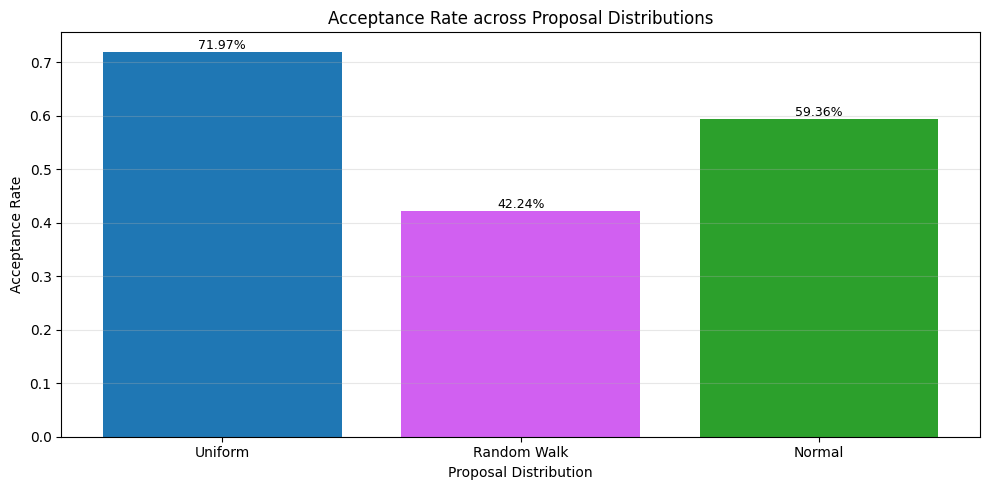

In [13]:
# Acceptance Rate Comparison

plt.figure(figsize=(10, 5))
plt.bar(performance_table["Proposal"],
      performance_table["Acceptance Rate"],
      color=[PROPOSAL_COLORS.get(p) for p in performance_table["Proposal"]]
)

plt.title("Acceptance Rate across Proposal Distributions")
plt.xlabel("Proposal Distribution")
plt.ylabel("Acceptance Rate")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(performance_table["Acceptance Rate"]):
    plt.text(i, value, f"{value:.2%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(
    "figures\\q2_acceptance_rate_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Extra Exploration

### Comparison of distribution as N increases

In [14]:
# ============================================================
# Further Exploration:
# Convergence comparison as N increases
# ============================================================

import contextlib
import io

# Discrete N values: 10, 50, 100, 150, ..., 10000
N_values = np.concatenate(([10], np.arange(50, 10001, 50)))


# Histogram settings for measuring distribution error
ERROR_BINS = 80
ERROR_RANGE = (-3, 3)

def distribution_l1_error(samples, bins=ERROR_BINS, x_range=ERROR_RANGE):
    """
    Compare empirical sampled distribution with the true density.
    Smaller L1 error means the sampled distribution is closer to the true distribution.
    """

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dx = bin_edges[1] - bin_edges[0]

    true_vals = target_fn(bin_centers, Z)

    l1_error = np.sum(np.abs(hist_density - true_vals)) * dx

    return l1_error


convergence_rows = []

for N_current in N_values:

    # Suppress acceptance-rate printing from universal_metropolis_sampler
    with contextlib.redirect_stdout(io.StringIO()):

        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=UNIFORM_STEP
        )

        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=RW_STEP
        )

        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            sigma=SIGMA
        )

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Uniform",
        "Distribution Error": distribution_l1_error(samples_uniform),
        "Acceptance Rate": acc_uniform
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Random Walk",
        "Distribution Error": distribution_l1_error(samples_rw),
        "Acceptance Rate": acc_rw
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Normal",
        "Distribution Error": distribution_l1_error(samples_normal),
        "Acceptance Rate": acc_normal
    })


convergence_df = pd.DataFrame(convergence_rows)

convergence_df.head()

,N,Proposal,Distribution Error,Acceptance Rate
0,10,Uniform,1.521856,0.777778
1,10,Random Walk,1.888327,0.333333
2,10,Normal,1.551982,0.555556
3,50,Uniform,0.946187,0.714286
4,50,Random Walk,1.859399,0.408163


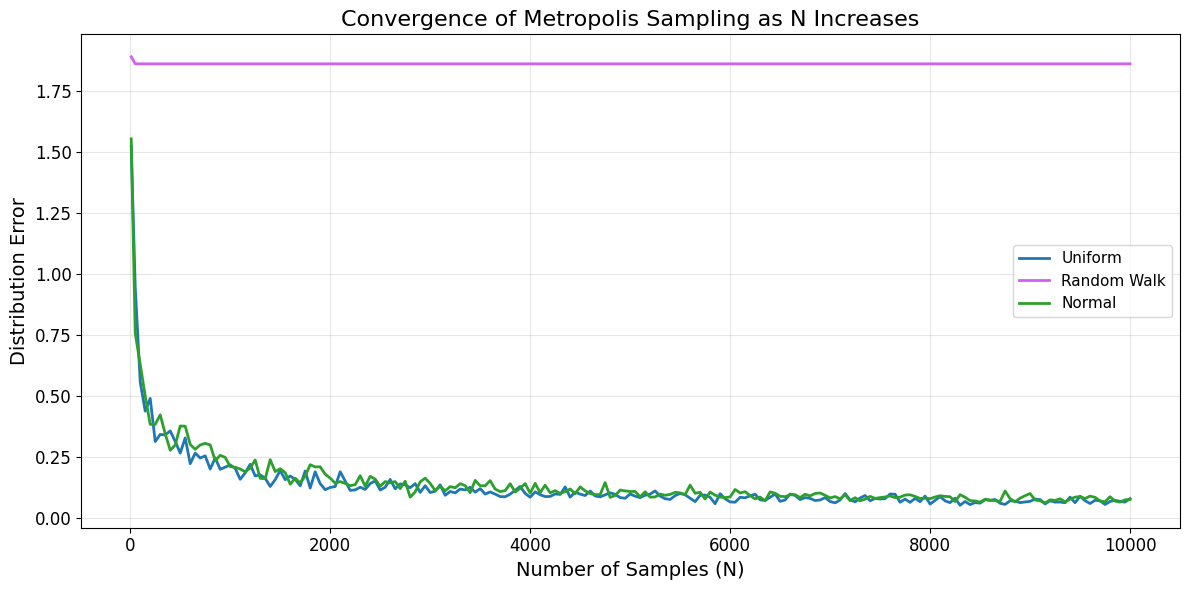

In [15]:
# ============================================================
# Plot convergence comparison
# ============================================================

PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Random Walk": RANDOM_WALK_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, ax = plt.subplots(figsize=(12, 6))

for proposal_name in ["Uniform", "Random Walk", "Normal"]:

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ]

    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=2,
        color=PROPOSAL_COLORS[proposal_name],
        label=proposal_name
    )

ax.set_title(
    "Convergence of Metropolis Sampling as N Increases",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_convergence_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# How to make random walk proposal more efficient?
# ============================================================
# Further Exploration:
# Compare Different Random Walk Step Sizes
# ============================================================

import contextlib
import io

N = 10000
INITIAL_X = 0.0

# Try different fixed random-walk step sizes
RW_STEP_VALUES = [
    0.01, 0.025, 0.05, 0.075,
    0.1, 0.2, 0.3, 0.5,
    0.75, 1.0, 2.0, 3.0
]


rw_step_results = []

for step in RW_STEP_VALUES:

    with contextlib.redirect_stdout(io.StringIO()):

        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    mean_estimate = np.mean(samples_rw)
    fourth_moment_estimate = np.mean(samples_rw**4)

    mean_error = abs(mean_estimate - 0)
    fourth_moment_error = abs(fourth_moment_estimate - 0.25)
    dist_error = distribution_l1_error(samples_rw)

    rw_step_results.append({
        "Step Size": step,
        "Acceptance Rate": acc_rw,
        "Mean Estimate": mean_estimate,
        "Mean Error": mean_error,
        "E[X^4] Estimate": fourth_moment_estimate,
        "E[X^4] Error": fourth_moment_error,
        "Distribution Error": dist_error
    })


rw_step_df = pd.DataFrame(rw_step_results)

rw_step_df

,Step Size,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
0,0.010,0.984998,-0.616369,0.616369,0.778533,0.528533,0.890418
1,0.025,0.980498,-0.511028,0.511028,0.392672,0.142672,0.848312
2,0.050,0.972797,-0.134440,0.134440,0.236138,0.013862,0.313276
3,0.075,0.960696,-0.018412,0.018412,0.249420,0.000580,0.090521
4,0.100,0.943494,-0.005130,0.005130,0.236730,0.013270,0.471150
5,0.200,0.884788,-0.022420,0.022420,0.253277,0.003277,1.162230
6,0.300,0.832683,-0.050550,0.050550,0.253357,0.003357,1.500006
7,0.500,0.723272,0.000750,0.000750,0.242994,0.007006,1.701835
8,0.750,0.602260,-0.004200,0.004200,0.213511,0.036489,1.795820
9,1.000,0.426543,0.001300,0.001300,0.426700,0.176700,1.859399


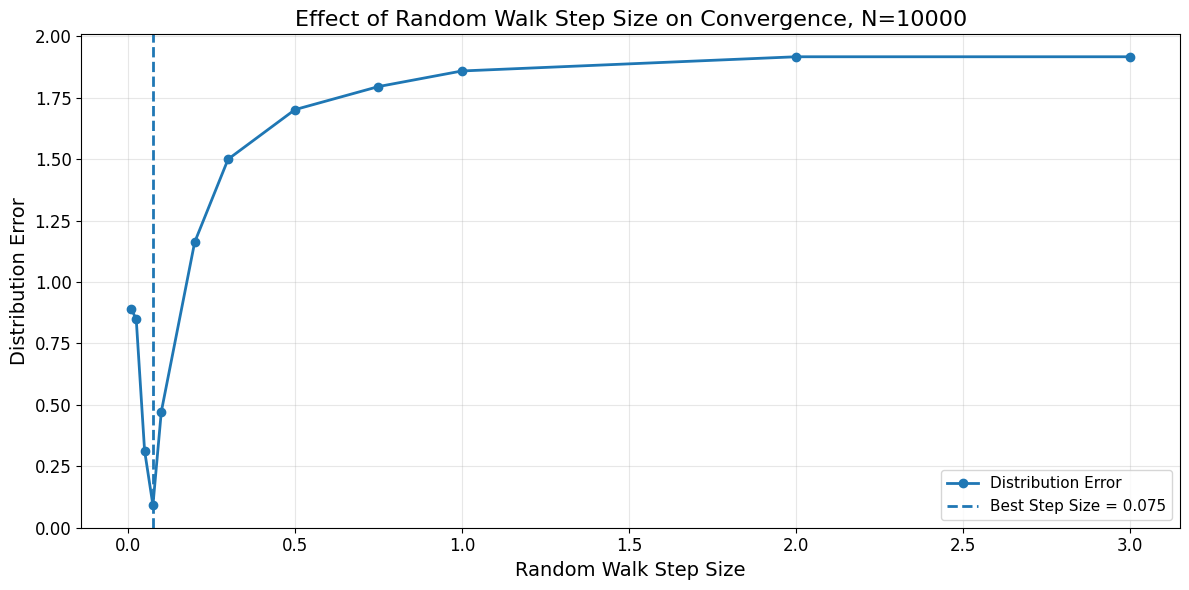

Best step size: 0.075
Lowest distribution error: 0.090521


In [17]:
# ============================================================
# Plot: Random Walk Step Size vs Distribution Error
# ============================================================

best_row = rw_step_df.loc[rw_step_df["Distribution Error"].idxmin()]
best_step = best_row["Step Size"]
best_error = best_row["Distribution Error"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rw_step_df["Step Size"],
    rw_step_df["Distribution Error"],
    marker="o",
    linewidth=2,
    label="Distribution Error"
)

ax.axvline(
    best_step,
    linestyle="--",
    linewidth=2,
    label=f"Best Step Size = {best_step}"
)

ax.set_title(
    f"Effect of Random Walk Step Size on Convergence, N={N}",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Random Walk Step Size", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_random_walk_step_size_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best step size: {best_step}")
print(f"Lowest distribution error: {best_error:.6f}")

In [21]:
# ============================================================
# Further Exploration:
# Compare Step Sizes Across
# Random Walk, Uniform, and Normal Proposals
# ============================================================

import contextlib
import io

N = 10000
INITIAL_X = 0.0

# Shared step/sigma values
STEP_VALUES = [
    0.01, 0.025, 0.05, 0.075,
    0.1, 0.2, 0.3, 0.5,
    0.75, 1.0, 2.0, 3.0
]

proposal_step_results = []

for step in STEP_VALUES:

    # ========================================================
    # Uniform Proposal
    # ========================================================

    with contextlib.redirect_stdout(io.StringIO()):

        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    uniform_mean_estimate = np.mean(samples_uniform)
    uniform_ex4_estimate = np.mean(samples_uniform**4)

    proposal_step_results.append({
        "Proposal": "Uniform",
        "Step Parameter": step,
        "Acceptance Rate": acc_uniform,
        "Mean Estimate": uniform_mean_estimate,
        "Mean Error": abs(uniform_mean_estimate),
        "E[X^4] Estimate": uniform_ex4_estimate,
        "E[X^4] Error": abs(uniform_ex4_estimate - 0.25),
        "Distribution Error": distribution_l1_error(samples_uniform)
    })


    # ========================================================
    # Random Walk Proposal
    # ========================================================

    with contextlib.redirect_stdout(io.StringIO()):

        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    rw_mean_estimate = np.mean(samples_rw)
    rw_ex4_estimate = np.mean(samples_rw**4)

    proposal_step_results.append({
        "Proposal": "Random Walk",
        "Step Parameter": step,
        "Acceptance Rate": acc_rw,
        "Mean Estimate": rw_mean_estimate,
        "Mean Error": abs(rw_mean_estimate),
        "E[X^4] Estimate": rw_ex4_estimate,
        "E[X^4] Error": abs(rw_ex4_estimate - 0.25),
        "Distribution Error": distribution_l1_error(samples_rw)
    })


    # ========================================================
    # Normal Proposal
    # ========================================================

    with contextlib.redirect_stdout(io.StringIO()):

        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            sigma=step
        )

    normal_mean_estimate = np.mean(samples_normal)
    normal_ex4_estimate = np.mean(samples_normal**4)

    proposal_step_results.append({
        "Proposal": "Normal",
        "Step Parameter": step,
        "Acceptance Rate": acc_normal,
        "Mean Estimate": normal_mean_estimate,
        "Mean Error": abs(normal_mean_estimate),
        "E[X^4] Estimate": normal_ex4_estimate,
        "E[X^4] Error": abs(normal_ex4_estimate - 0.25),
        "Distribution Error": distribution_l1_error(samples_normal)
    })


# ============================================================
# Convert to DataFrame
# ============================================================

proposal_step_df = pd.DataFrame(proposal_step_results)

proposal_step_df

,Proposal,Step Parameter,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
0,Uniform,0.010,0.999900,-0.016197,0.016197,0.001636,0.248364,1.307858
1,Random Walk,0.010,0.995400,0.463127,0.463127,0.192024,0.057976,0.933808
2,Normal,0.010,0.998300,-0.352041,0.352041,0.086095,0.163905,0.939807
3,Uniform,0.025,0.989099,0.478856,0.478856,0.423870,0.173870,0.713263
4,Random Walk,0.025,0.989199,-0.112778,0.112778,0.186607,0.063393,0.325546
5,Normal,0.025,0.988099,0.380851,0.380851,0.286776,0.036776,0.646373
6,Uniform,0.050,0.991099,0.007770,0.007770,0.152056,0.097944,0.372309
7,Random Walk,0.050,0.973897,0.018535,0.018535,0.209029,0.040971,0.329121
8,Normal,0.050,0.973297,-0.104727,0.104727,0.281762,0.031762,0.186642
9,Uniform,0.075,0.982698,0.026598,0.026598,0.214208,0.035792,0.232768


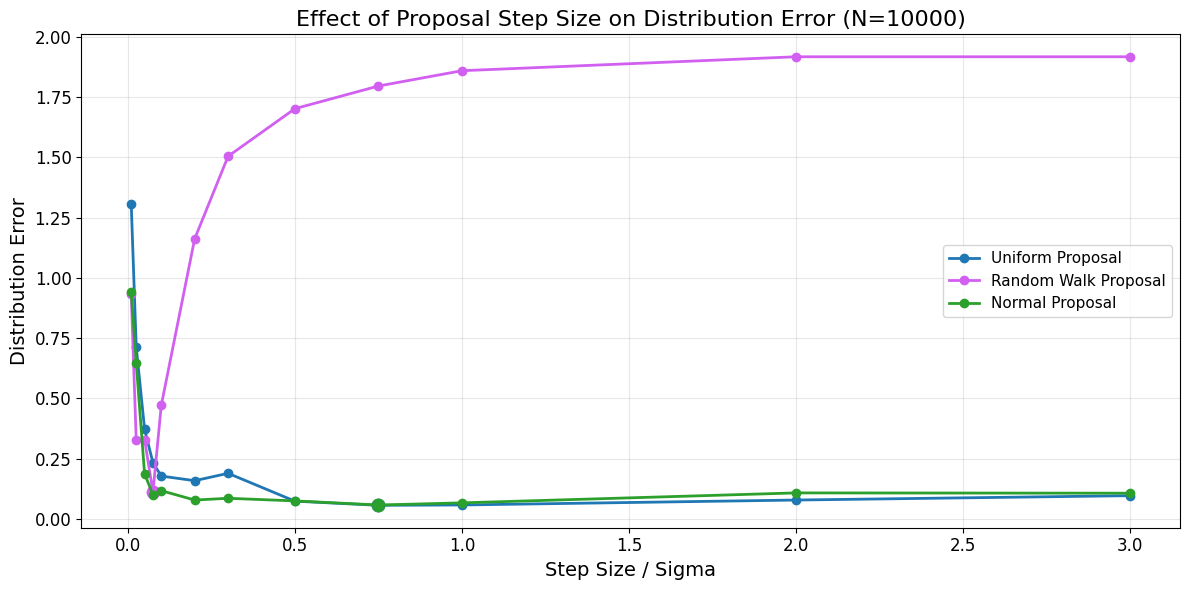

Best Uniform Step: 0.75
Best Random Walk Step: 0.075
Best Normal Sigma: 0.75


In [22]:
# ============================================================
# Plot Distribution Error vs Step Size for All 3 Proposals
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ---------- Uniform Proposal ----------
uniform_df = proposal_step_df[
    proposal_step_df["Proposal"] == "Uniform"
]

ax.plot(
    uniform_df["Step Parameter"],
    uniform_df["Distribution Error"],
    marker="o",
    linewidth=2,
    color=UNIFORM_COLOR,
    label="Uniform Proposal"
)

# ---------- Random Walk Proposal ----------
rw_df = proposal_step_df[
    proposal_step_df["Proposal"] == "Random Walk"
]

ax.plot(
    rw_df["Step Parameter"],
    rw_df["Distribution Error"],
    marker="o",
    linewidth=2,
    color=RANDOM_WALK_COLOR,
    label="Random Walk Proposal"
)

# ---------- Normal Proposal ----------
normal_df = proposal_step_df[
    proposal_step_df["Proposal"] == "Normal"
]

ax.plot(
    normal_df["Step Parameter"],
    normal_df["Distribution Error"],
    marker="o",
    linewidth=2,
    color=NORMAL_COLOR,
    label="Normal Proposal"
)

# Best points
best_uniform = uniform_df.loc[uniform_df["Distribution Error"].idxmin()]
best_rw = rw_df.loc[rw_df["Distribution Error"].idxmin()]
best_normal = normal_df.loc[normal_df["Distribution Error"].idxmin()]

ax.scatter(
    best_uniform["Step Parameter"],
    best_uniform["Distribution Error"],
    s=80,
    color=UNIFORM_COLOR
)

ax.scatter(
    best_rw["Step Parameter"],
    best_rw["Distribution Error"],
    s=80,
    color=RANDOM_WALK_COLOR
)

ax.scatter(
    best_normal["Step Parameter"],
    best_normal["Distribution Error"],
    s=80,
    color=NORMAL_COLOR
)

ax.set_title(
    f"Effect of Proposal Step Size on Distribution Error (N={N})",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Step Size / Sigma", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis='both', labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)

ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_step_size_distribution_error.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Best Uniform Step:", best_uniform["Step Parameter"])
print("Best Random Walk Step:", best_rw["Step Parameter"])
print("Best Normal Sigma:", best_normal["Step Parameter"])

In [27]:
# ============================================================
# Further Exploration:
# Plot the distribution of samples for the best random walk step size
# ============================================================

# Best random walk step size from previous analysis
UNIFORM_STEP = 0.75
RW_STEP = 0.075
SIGMA = 0.75


convergence_rows = []

for N_current in N_values:

    # Suppress acceptance-rate printing from universal_metropolis_sampler
    with contextlib.redirect_stdout(io.StringIO()):

        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=UNIFORM_STEP
        )

        samples_rw, acc_rw = universal_metropolis_sampler(
            dist="rw",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=RW_STEP
        )

        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            sigma=SIGMA
        )

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Uniform",
        "Distribution Error": distribution_l1_error(samples_uniform),
        "Acceptance Rate": acc_uniform
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Random Walk",
        "Distribution Error": distribution_l1_error(samples_rw),
        "Acceptance Rate": acc_rw
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Normal",
        "Distribution Error": distribution_l1_error(samples_normal),
        "Acceptance Rate": acc_normal
    })


convergence_df = pd.DataFrame(convergence_rows)

convergence_df.head()

,N,Proposal,Distribution Error,Acceptance Rate
0,10,Uniform,1.508673,0.777778
1,10,Random Walk,1.586494,1.000000
2,10,Normal,1.360790,0.888889
3,50,Uniform,0.663320,0.795918
4,50,Random Walk,1.367934,0.979592


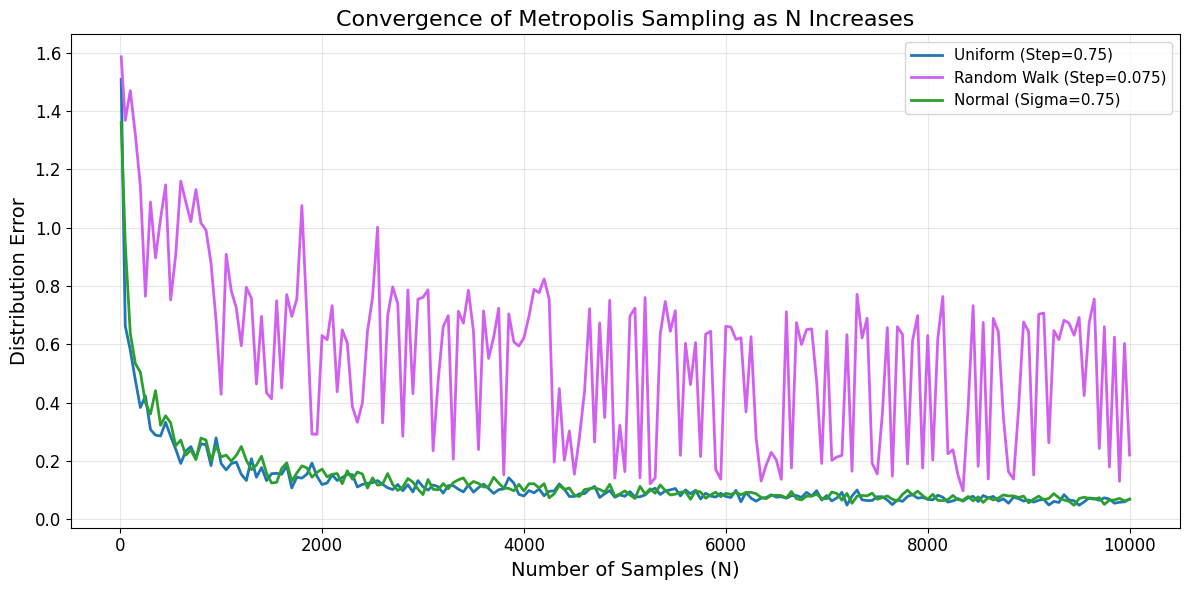

In [28]:
# ============================================================
# Plot convergence comparison
# ============================================================

PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Random Walk": RANDOM_WALK_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, ax = plt.subplots(figsize=(12, 6))

for proposal_name in ["Uniform", "Random Walk", "Normal"]:

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ]

    label_name = proposal_name
    if proposal_name == "Random Walk":
        label_name += f" (Step={RW_STEP})"
    elif proposal_name == "Uniform":
        label_name += f" (Step={UNIFORM_STEP})"
    elif proposal_name == "Normal":
        label_name += f" (Sigma={SIGMA})"


    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=2,
        color=PROPOSAL_COLORS[proposal_name],
        label=label_name 
    )

ax.set_title(
    "Convergence of Metropolis Sampling as N Increases",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_convergence_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Plot 3 Distribution Using Larger N and optimal step size

Acceptance rate: 0.7952
Acceptance rate: 0.9534
Acceptance rate: 0.6774


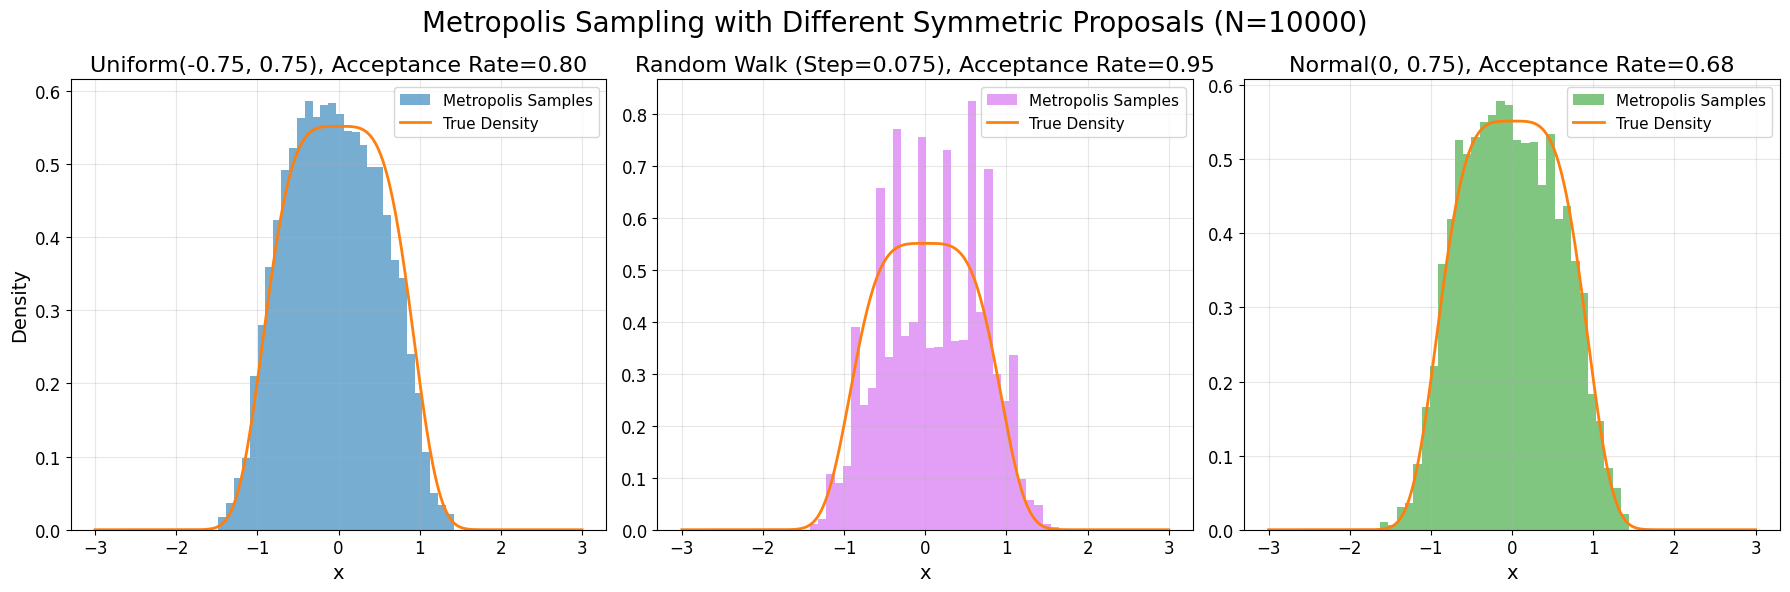

In [29]:
N = 10000

metropolis_results = {}
# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=UNIFORM_STEP)
samples_rw, acc_rw = universal_metropolis_sampler(dist="rw", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=RW_STEP)
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=SIGMA)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# ---------- First plot ----------
ax[0].hist(samples_uniform,
           bins=B1,
           density=True,
           alpha=0.6,
           color=UNIFORM_COLOR,
           label="Metropolis Samples")

ax[0].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[0].set_title(
    f"Uniform(-{UNIFORM_STEP}, {UNIFORM_STEP}), Acceptance Rate={acc_uniform:.2f}",
    fontsize=TITLE_SIZE
)

ax[0].set_xlabel("x", fontsize=LABEL_SIZE)
ax[0].set_ylabel("Density", fontsize=LABEL_SIZE)

ax[0].tick_params(axis='both', labelsize=TICK_SIZE)

ax[0].grid(True, alpha=0.3)

ax[0].legend(fontsize=LEGEND_SIZE)

# ---------- Second plot ----------
ax[1].hist(samples_rw,
           bins=B2,
           density=True,
           alpha=0.6,
           color=RANDOM_WALK_COLOR,
           label="Metropolis Samples")

ax[1].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[1].set_title(
    f"Random Walk (Step={RW_STEP}), Acceptance Rate={acc_rw:.2f}",
    fontsize=TITLE_SIZE
)

ax[1].set_xlabel("x", fontsize=LABEL_SIZE)

ax[1].tick_params(axis='both', labelsize=TICK_SIZE)

ax[1].grid(True, alpha=0.3)

ax[1].legend(fontsize=LEGEND_SIZE)

# ---------- Third plot ----------
ax[2].hist(samples_normal,
           bins=B3,
           density=True,
           alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

ax[2].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label="True Density")

ax[2].set_title(
    f"Normal(0, {SIGMA}), Acceptance Rate={acc_normal:.2f}",
    fontsize=TITLE_SIZE
)

ax[2].set_xlabel("x", fontsize=LABEL_SIZE)

ax[2].tick_params(axis='both', labelsize=TICK_SIZE)

ax[2].grid(True, alpha=0.3)

ax[2].legend(fontsize=LEGEND_SIZE)

# Global title
plt.suptitle(
    f"Metropolis Sampling with Different Symmetric Proposals (N={N})",
    fontsize=20,
)

# Better spacing
plt.tight_layout()

# High quality export
plt.savefig(
    "figures\\q2_compare_proposals.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

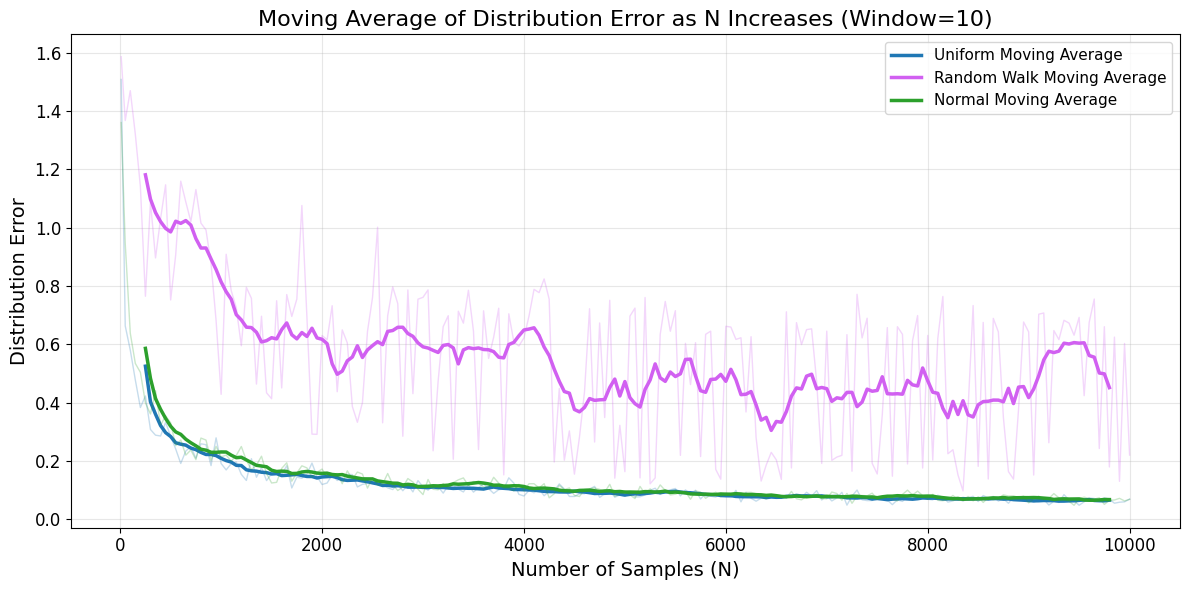

In [30]:
# ============================================================
# Moving Average Plot for Distribution Error
# ============================================================

MOVING_AVG_WINDOW = 10   # try 10 or 20

fig, ax = plt.subplots(figsize=(12, 6))

proposal_styles = {
    "Uniform": {
        "color": UNIFORM_COLOR,
        "label": "Uniform"
    },
    "Random Walk": {
        "color": RANDOM_WALK_COLOR,
        "label": "Random Walk"
    },
    "Normal": {
        "color": NORMAL_COLOR,
        "label": "Normal"
    }
}

for proposal_name, style in proposal_styles.items():

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ].sort_values("N").copy()

    proposal_df["Moving Average"] = (
        proposal_df["Distribution Error"]
        .rolling(window=MOVING_AVG_WINDOW, center=True)
        .mean()
    )

    # Raw line, lighter
    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=1,
        alpha=0.25,
        color=style["color"]
    )

    # Moving average line
    ax.plot(
        proposal_df["N"],
        proposal_df["Moving Average"],
        linewidth=2.5,
        color=style["color"],
        label=f"{style['label']} Moving Average"
    )

ax.set_title(
    f"Moving Average of Distribution Error as N Increases "
    f"(Window={MOVING_AVG_WINDOW})",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "figures\\q2_convergence_moving_average.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()